##### Setup

###### Imports

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


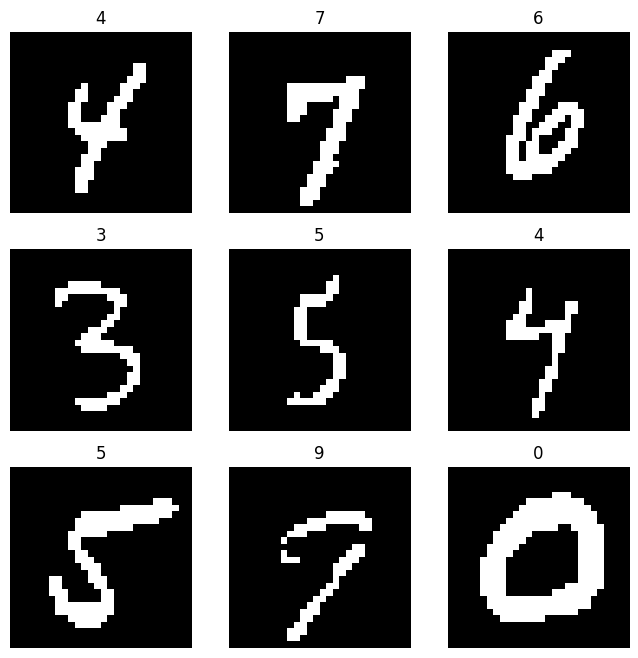

In [4]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def latentSpaceRecons2D(model, n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


##### MNIST

###### Vector Quantized VAE

In [9]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [10]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
data_var = 100.

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model_vq = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim,
                                    nEmbeddings=n_embeds, beta=beta,
                                    data_var=data_var).to(device)

In [11]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vq.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [12]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model_vq.train()
    encoderParams = list(model_vq.encoder.parameters())

    losses = model_vq.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model_vq, batch)

recon grad norm (encoder): 50.7433
vq grad norm (encoder):    0.4004
ratio reconGradNorm/vqGradNorm -> suggested data_var: 126.7252


In [13]:
model_vq.trainLoop(trainLoader, optimizer, epochs, 
                   reportIters=100, scheduler=None,
                   checkpointPath='../checkpoints/mnist_vqvae/',
                   checkPointName='vqvae_16_10',
                   validDataLoader=validLoader,
                   earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 2.614046 reconLoss: 144.489319 codeLoss: 0.584576 commLoss: 0.584576 vqLoss: 1.169152[12800/60000]
totalLoss: 2.610136 reconLoss: 125.783150 codeLoss: 0.676152 commLoss: 0.676152 vqLoss: 1.352304[25600/60000]
totalLoss: 2.907017 reconLoss: 105.285210 codeLoss: 0.927083 commLoss: 0.927083 vqLoss: 1.854165[38400/60000]
totalLoss: 2.739092 reconLoss: 93.590179 codeLoss: 0.901595 commLoss: 0.901595 vqLoss: 1.803190[51200/60000]
Validation Error: 2.728338
Epoch 2
-------------------------------
totalLoss: 2.901247 reconLoss: 94.030296 codeLoss: 0.980472 commLoss: 0.980472 vqLoss: 1.960944[12800/60000]
totalLoss: 3.124901 reconLoss: 89.587234 codeLoss: 1.114514 commLoss: 1.114514 vqLoss: 2.229029[25600/60000]
totalLoss: 3.506057 reconLoss: 89.310799 codeLoss: 1.306475 commLoss: 1.306475 vqLoss: 2.612949[38400/60000]
totalLoss: 3.650814 reconLoss: 96.072975 codeLoss: 1.345042 commLoss: 1.345042 vqLoss: 2.690084[51200/60000]
Validation Error: 

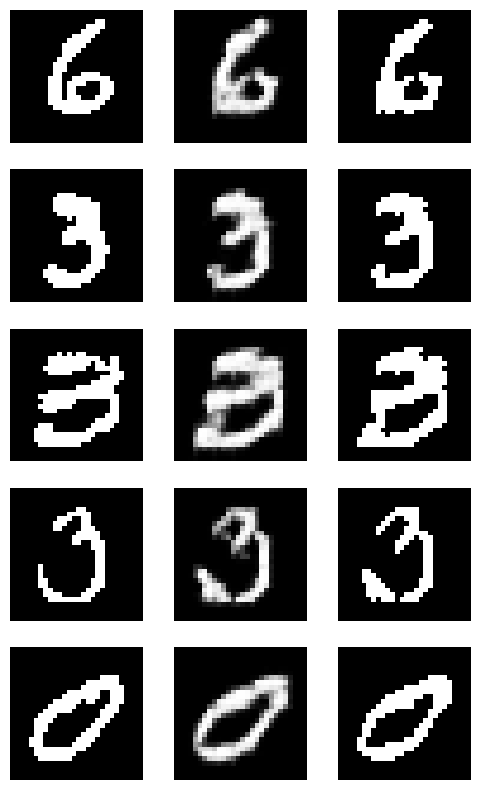

In [14]:
nCols = 3
nRows = 5

figure = plt.figure(figsize=(6, 10))
model_vq.eval()

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vq.decode(model_vq.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

###### Autoencoding VAE

In [19]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model_vae = variationalAutoencoder(encoder, decoder).to(device)
model_vae.load_state_dict(torch.load('../checkpoints/mnist_vae/vae_2-13.model', weights_only=True)['model_state_dict'])

<All keys matched successfully>

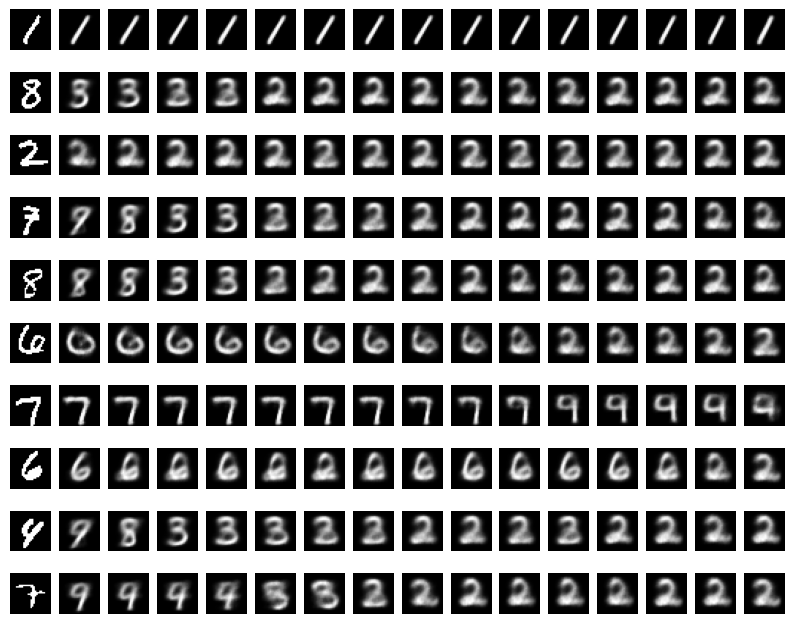

In [20]:
nCols = 16
nRows = 10

model_vae.eval()

figure = plt.figure(figsize=(10, 8))
idxs = []
with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        idxs.append(sidx)
        img = trainImageData[sidx].unsqueeze(0).to(device)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model_vae.forward(img)[0]
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

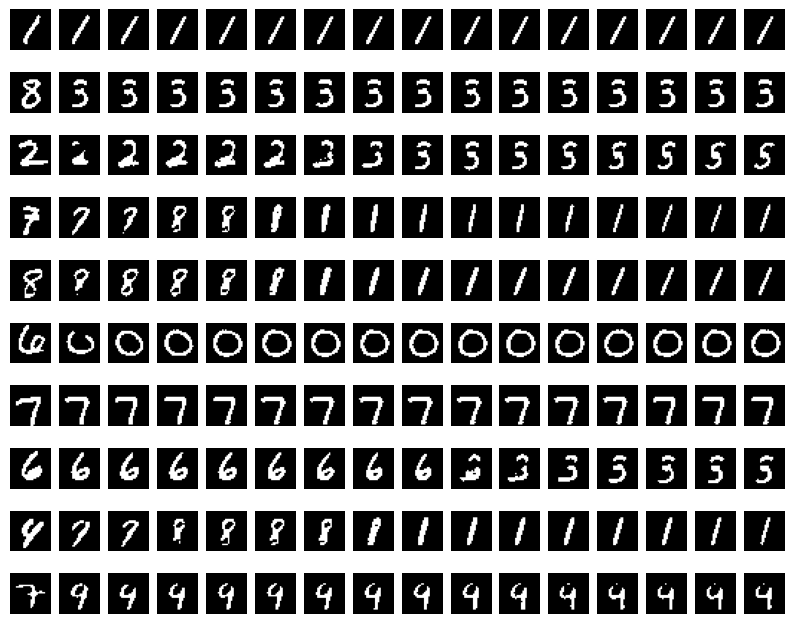

In [21]:
figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        img = torch.where(img > 0.5, 1.0, 0.0)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model_vae.forward(img)[0]
            img = torch.where(img > 0.5, 1.0, 0.0)
            
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

In [22]:
# build the encoder and decoder networks
hid_dim = 4

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

model_avae = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.995).to(device)

In [23]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_avae.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.1, mode='min', restoreBestWeights=True)

In [24]:
model_avae.trainLoop(trainLoader, optimizer, epochs, 
                     reportIters=100, scheduler=None,
                     checkpointPath='../checkpoints/mnist_avae/',
                     checkPointName='avae_98',
                     validDataLoader=validLoader,
                     earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 206.734695 reconLoss: 202.072922 klLoss: 2.798814 condLoss: 1.862955[12800/60000]
totalLoss: 158.473282 reconLoss: 154.521301 klLoss: 2.870450 condLoss: 1.081524[25600/60000]
totalLoss: 151.117279 reconLoss: 147.464478 klLoss: 2.875512 condLoss: 0.777287[38400/60000]
totalLoss: 138.935562 reconLoss: 135.328812 klLoss: 3.051418 condLoss: 0.555335[51200/60000]
Validation Error: 135.081925
Epoch 2
-------------------------------
totalLoss: 133.874603 reconLoss: 130.204559 klLoss: 3.153472 condLoss: 0.516565[12800/60000]
totalLoss: 132.235458 reconLoss: 128.685669 klLoss: 3.167028 condLoss: 0.382774[25600/60000]
totalLoss: 131.711166 reconLoss: 127.956116 klLoss: 3.305622 condLoss: 0.449434[38400/60000]
totalLoss: 124.652817 reconLoss: 120.807541 klLoss: 3.437523 condLoss: 0.407751[51200/60000]
Validation Error: 126.067253
Epoch 3
-------------------------------
totalLoss: 121.534538 reconLoss: 117.732880 klLoss: 3.323852 condLoss: 0.47780

In [25]:
if hid_dim==2:
    latentSpaceRecons2D(model_avae, scale=2.0, n=30)

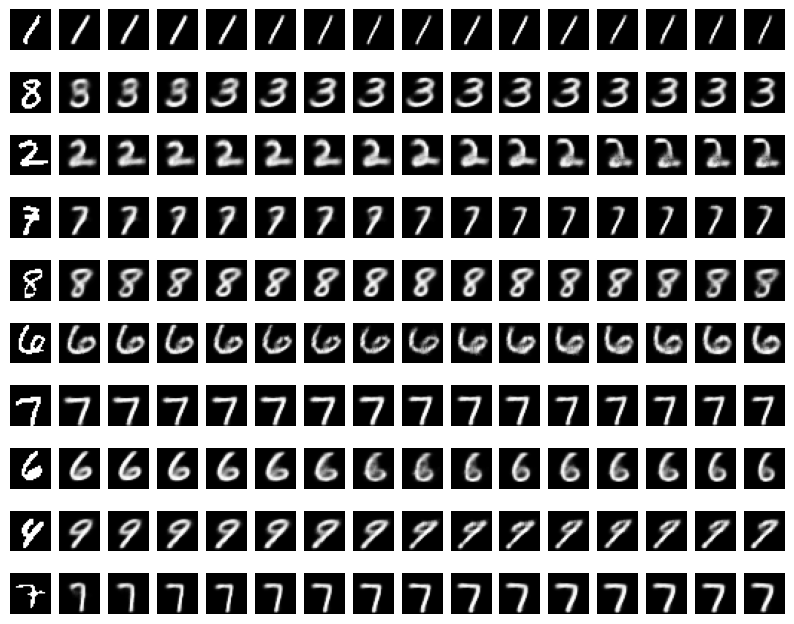

In [26]:
model_avae.eval()

figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model_avae.forward(img)[0]
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()

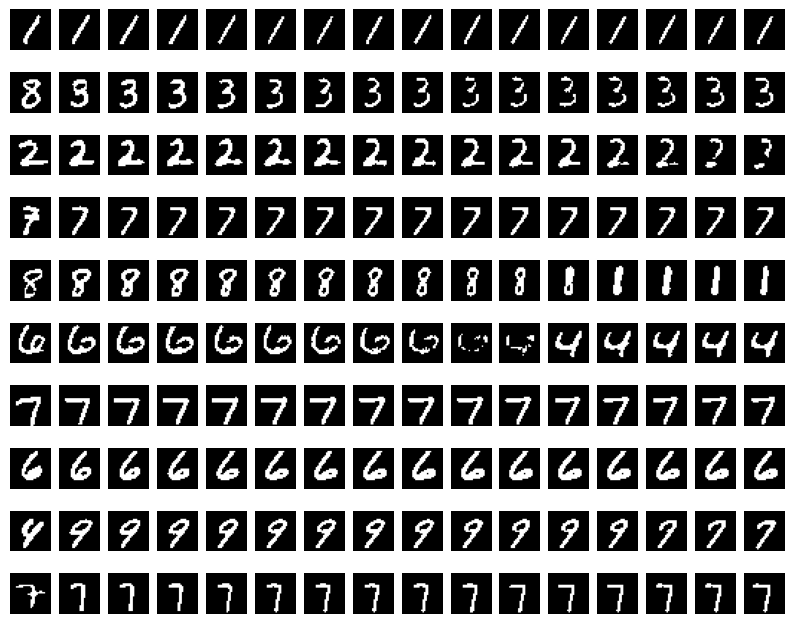

In [27]:
figure = plt.figure(figsize=(10, 8))
with torch.no_grad():
    for i in range(nRows):
        sidx = idxs[i]
        img = trainImageData[sidx].unsqueeze(0).to(device)
        img = torch.where(img > 0.5, 1.0, 0.0)
        
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

        for j in range(1, nCols):
            img = model_avae.forward(img)[0]
            img = torch.where(img > 0.5, 1.0, 0.0)
            
            figure.add_subplot(nRows, nCols, nCols * i + j + 1)
            plt.axis("off")
            plt.imshow(img.cpu().detach().numpy().squeeze(), cmap='gray')

plt.show()